<a href="https://colab.research.google.com/github/shomere/formative_2group3_ml_techs1_swac/blob/main/bilstm_submission_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Quick check to ensure Drive is connected
if os.path.exists('/content/drive/MyDrive'):
    print("✓ Google Drive mounted successfully!")
else:
    print("❌ Drive mount failed. Please re-run and authorize access.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully!


In [7]:
!rm -rf /content/Swahili_words.zip
!rm -rf /content/Swahili_words
!rm -rf /content/Train.csv
print("✓ Colab workspace cleaned.")

✓ Colab workspace cleaned.


In [8]:
!rm -rf /content/Swahili_words.zip
print("✓ Corrupted file deleted.")

✓ Corrupted file deleted.


In [9]:
import os

zip_path_local = '/content/Swahili_words.zip'

if not os.path.exists(zip_path_local):
    print("❌ ERROR: Swahili_words.zip was not found in /content/")
else:
    size_mb = os.path.getsize(zip_path_local) / (1024 * 1024)
    print(f"File size in /content/: {size_mb:.2f} MB")

    if size_mb < 500:
        print("❌ WARNING: Zip file is incomplete (< 500 MB).")
        print("--> The upload was interrupted. Re-upload Swahili_words.zip to Colab or Google Drive.")
    else:
        print("✓ Local zip file size looks good (~506 MB)!")

❌ ERROR: Swahili_words.zip was not found in /content/


In [10]:
!cp /content/drive/MyDrive/Swahili_words.zip /content/
!cp /content/drive/MyDrive/Train.csv /content/

# Verify local file sizes
!ls -lh /content/Swahili_words.zip
!ls -lh /content/Train.csv

cp: cannot stat '/content/drive/MyDrive/Swahili_words.zip': No such file or directory
ls: cannot access '/content/Swahili_words.zip': No such file or directory
-rw------- 1 root root 123K Oct  2 08:31 /content/Train.csv


In [11]:
import os
import pandas as pd

# 1. Copy unzipped Swahili_words folder from Drive to Colab
print("Copying Swahili_words folder from Drive to Colab... (takes ~1-2 minutes)")
!cp -r /content/drive/MyDrive/Swahili_words /content/

# 2. Sanity check
train_path = '/content/Train.csv'
audio_dir = '/content/Swahili_words'

if os.path.exists(train_path) and os.path.exists(audio_dir):
    df_train = pd.read_csv(train_path)
    audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.wav')]

    print("\n=== DATASET SANITY CHECK ===")
    print(f"✓ Train metadata rows: {len(df_train)}")
    print(f"✓ Extracted .wav files: {len(audio_files)}")
    print("\nFirst 3 rows of Train.csv:")
    display(df_train.head(3))
else:
    print("\n❌ Swahili_words folder not found. Double-check its exact name in drive.google.com.")

Copying Swahili_words folder from Drive to Colab... (takes ~1-2 minutes)

=== DATASET SANITY CHECK ===
✓ Train metadata rows: 4200
✓ Extracted .wav files: 4849

First 3 rows of Train.csv:


,Word_id,Swahili_word,English_translation
0,id_v8rz06e6rv31.wav,mbili,two
1,id_vmbwicdpfn68.wav,tatu,three
2,id_injlouhxg1hg.wav,ndio,yes


In [16]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

df_train = pd.read_csv('/content/Train.csv')
audio_dir = '/content/Swahili_words'

TARGET_SR = 16000
MAX_DURATION = 2.0  # Pad or cut clips to exactly 2.0 seconds
N_MELS = 64
FIXED_LENGTH = int(TARGET_SR * MAX_DURATION)

def extract_mel_sequence(file_path):
    # Load audio at fixed sample rate
    y, sr = librosa.load(file_path, sr=TARGET_SR)

    # Trim leading/trailing silence
    y, _ = librosa.effects.trim(y, top_db=20)

    # Pad or truncate to fixed duration
    if len(y) < FIXED_LENGTH:
        y = np.pad(y, (0, FIXED_LENGTH - len(y)), mode='constant')
    else:
        y = y[:FIXED_LENGTH]

    # Extract Log-Mel Spectrogram (Shape: [N_MELS, Time_Frames])
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=1024, hop_length=512)
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    return log_mel

print("Extracting Log-Mel feature sequences for all training samples...")
features = []
labels = []

label_mapping = {word: idx for idx, word in enumerate(df_train['Swahili_word'].unique())}
inv_label_mapping = {idx: word for word, idx in label_mapping.items()}

for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
    wid = row['Word_id']
    fpath = os.path.join(audio_dir, wid if wid.endswith('.wav') else f"{wid}.wav")

    if os.path.exists(fpath):
        mel_seq = extract_mel_sequence(fpath)
        features.append(mel_seq)
        labels.append(label_mapping[row['Swahili_word']])

X = np.array(features)  # Shape: (4200, 64, 63)
y = np.array(labels)

print(f"\n✓ Feature extraction complete!")
print(f"Feature matrix shape (X): {X.shape}")
print(f"Target vector shape (y):  {y.shape}")

Extracting Log-Mel feature sequences for all training samples...


100%|██████████| 4200/4200 [00:40<00:00, 102.81it/s]


✓ Feature extraction complete!
Feature matrix shape (X): (3386, 64, 63)
Target vector shape (y):  (3386,)


In [17]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Transpose X to shape (N_samples, Time_Frames, N_MELS) so length is over time
X_seq = np.transpose(X, (0, 2, 1))

# Stratified Train/Val Split (80% Train, 20% Val)
X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y, test_size=0.20, random_state=42, stratify=y
)

# PyTorch Dataset Class
class AudioSequenceDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AudioSequenceDataset(X_train, y_train)
val_dataset = AudioSequenceDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"✓ Sequence datasets created:")
print(f"  Train shape: {X_train.shape} -> {len(train_dataset)} samples")
print(f"  Val shape:   {X_val.shape} -> {len(val_dataset)} samples")

✓ Sequence datasets created:
  Train shape: (2708, 63, 64) -> 2708 samples
  Val shape:   (678, 63, 64) -> 678 samples


In [18]:
class BiLSTMAudioClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, num_layers=2, num_classes=12, dropout=0.3):
        super(BiLSTMAudioClassifier, self).__init__()

        # BiLSTM Layer
        self.bilstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Attention Layer across time steps
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # Output Classification Head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.bilstm(x) # (batch_size, seq_len, hidden_dim * 2)

        attn_weights = self.attention(lstm_out) # (batch_size, seq_len, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)

        context = torch.sum(attn_weights * lstm_out, dim=1) # (batch_size, hidden_dim * 2)
        logits = self.fc(context)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BiLSTMAudioClassifier(num_classes=len(label_mapping)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"✓ BiLSTM Model initialized on device: {device}")
print(model)

✓ BiLSTM Model initialized on device: cuda
BiLSTMAudioClassifier(
  (bilstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=12, bias=True)
  )
)


In [19]:
class BiLSTMAudioClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, num_layers=2, num_classes=12, dropout=0.3):
        super(BiLSTMAudioClassifier, self).__init__()

        # BiLSTM Layer
        self.bilstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Attention Layer across time steps
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # Output Classification Head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.bilstm(x) # (batch_size, seq_len, hidden_dim * 2)

        attn_weights = self.attention(lstm_out) # (batch_size, seq_len, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)

        context = torch.sum(attn_weights * lstm_out, dim=1) # (batch_size, hidden_dim * 2)
        logits = self.fc(context)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BiLSTMAudioClassifier(num_classes=len(label_mapping)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"✓ BiLSTM Model initialized on device: {device}")
print(model)

✓ BiLSTM Model initialized on device: cuda
BiLSTMAudioClassifier(
  (bilstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=12, bias=True)
  )
)


In [22]:
from sklearn.metrics import f1_score

epochs = 25
best_val_f1 = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, epochs + 1):
    # Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation Phase
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    val_preds_all, val_targets_all = [], []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

            val_preds_all.extend(preds.cpu().numpy())
            val_targets_all.extend(targets.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(val_targets_all, val_preds_all, average='macro')

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch:02d}/{epochs}] | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} Macro-F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_bilstm_model.pt')

print(f"\n✓ Training complete! Best Validation Macro-F1: {best_val_f1:.4f}")

Epoch [01/25] | Train Loss: 2.4067 Acc: 0.1196 | Val Loss: 2.2946 Acc: 0.1785 Macro-F1: 0.0874
Epoch [02/25] | Train Loss: 2.1531 Acc: 0.2153 | Val Loss: 2.0256 Acc: 0.2847 Macro-F1: 0.2190
Epoch [03/25] | Train Loss: 1.8221 Acc: 0.3408 | Val Loss: 1.7189 Acc: 0.4012 Macro-F1: 0.3708
Epoch [04/25] | Train Loss: 1.5731 Acc: 0.4284 | Val Loss: 1.3898 Acc: 0.5457 Macro-F1: 0.5168
Epoch [05/25] | Train Loss: 1.4069 Acc: 0.5122 | Val Loss: 1.2965 Acc: 0.5693 Macro-F1: 0.5443
Epoch [06/25] | Train Loss: 1.1872 Acc: 0.5890 | Val Loss: 0.9609 Acc: 0.6726 Macro-F1: 0.6553
Epoch [07/25] | Train Loss: 1.0233 Acc: 0.6651 | Val Loss: 0.9057 Acc: 0.7065 Macro-F1: 0.7036
Epoch [08/25] | Train Loss: 0.9907 Acc: 0.6721 | Val Loss: 0.7382 Acc: 0.7699 Macro-F1: 0.7653
Epoch [09/25] | Train Loss: 0.8527 Acc: 0.7293 | Val Loss: 0.7890 Acc: 0.7389 Macro-F1: 0.7409
Epoch [10/25] | Train Loss: 0.8039 Acc: 0.7411 | Val Loss: 0.6205 Acc: 0.8083 Macro-F1: 0.8080
Epoch [11/25] | Train Loss: 0.7808 Acc: 0.7463 | V

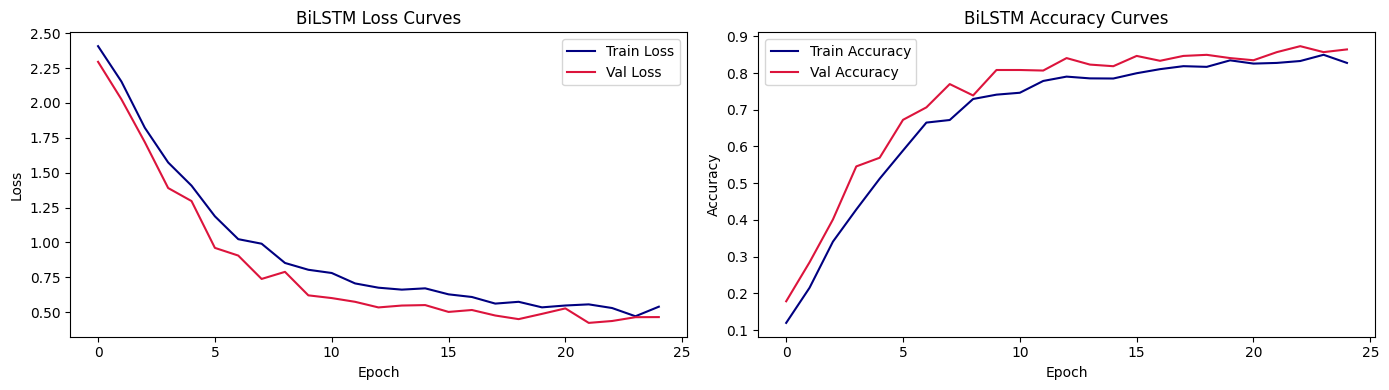

=== BILSTM CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       mbili       0.78      0.89      0.84        57
        tatu       0.81      0.96      0.88        56
        ndio       0.89      0.88      0.88        57
         nne       0.79      0.75      0.77        55
        nane       1.00      0.81      0.89        57
      hapana       0.98      0.86      0.91        56
        sita       1.00      0.84      0.91        56
        tisa       0.87      1.00      0.93        55
        moja       0.83      0.88      0.85        57
        saba       0.96      0.81      0.88        57
        tano       0.78      0.85      0.81        59
        kumi       0.89      0.96      0.92        56

    accuracy                           0.87       678
   macro avg       0.88      0.87      0.87       678
weighted avg       0.88      0.87      0.87       678



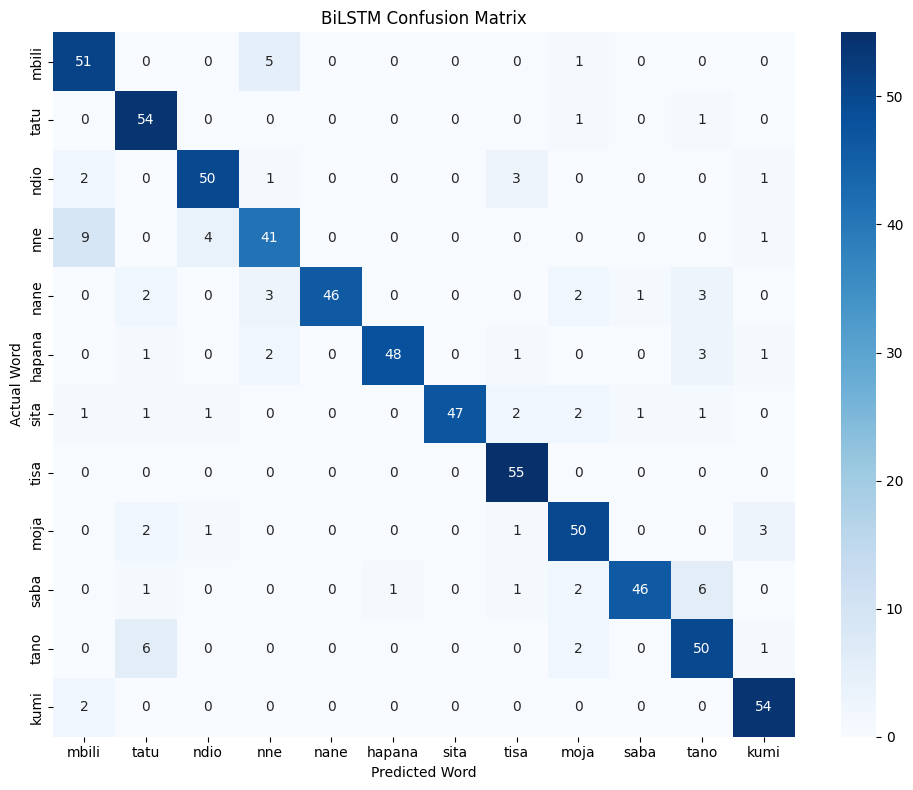

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses, label='Train Loss', color='navy')
axes[0].plot(val_losses, label='Val Loss', color='crimson')
axes[0].set_title('BiLSTM Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_accs, label='Train Accuracy', color='navy')
axes[1].plot(val_accs, label='Val Accuracy', color='crimson')
axes[1].set_title('BiLSTM Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Evaluation Metrics
model.load_state_dict(torch.load('best_bilstm_model.pt'))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        y_true.extend(targets.numpy())
        y_pred.extend(outputs.argmax(dim=1).cpu().numpy())

target_names = [inv_label_mapping[i] for i in range(len(inv_label_mapping))]

print("=== BILSTM CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('BiLSTM Confusion Matrix')
plt.xlabel('Predicted Word')
plt.ylabel('Actual Word')
plt.tight_layout()
plt.show()

In [26]:
import os

# Copy Test.csv from Drive
!cp /content/drive/MyDrive/Test.csv /content/

if os.path.exists('/content/Test.csv'):
    print("✓ Test.csv successfully copied to /content!")
else:
    print("❌ Test.csv not found in Google Drive root. Please upload Test.csv to drive.google.com first.")

✓ Test.csv successfully copied to /content!


In [27]:
test_csv_path = '/content/Test.csv'

if os.path.exists(test_csv_path):
    df_test = pd.read_csv(test_csv_path)
    test_features = []
    valid_test_ids = []

    print("Processing test audio files...")
    for wid in tqdm(df_test['Word_id']):
        fpath = os.path.join(audio_dir, wid if wid.endswith('.wav') else f"{wid}.wav")
        if os.path.exists(fpath):
            mel_seq = extract_mel_sequence(fpath)
            test_features.append(mel_seq)
            valid_test_ids.append(wid)

    X_test = np.array(test_features)
    X_test_seq = np.transpose(X_test, (0, 2, 1))

    X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_tensor)
        test_preds = test_logits.argmax(dim=1).cpu().numpy()

    df_sub = pd.DataFrame({
        'Word_id': valid_test_ids,
        'Swahili_word': [inv_label_mapping[p] for p in test_preds]
    })

    df_sub.to_csv('bilstm_submission.csv', index=False)
    print("✓ Submission file saved to bilstm_submission.csv!")
    display(df_sub.head())
else:
    print("Test.csv not uploaded to /content/. Step 5 skipped.")

Processing test audio files...


100%|██████████| 1800/1800 [00:07<00:00, 249.88it/s]


✓ Submission file saved to bilstm_submission.csv!


,Word_id,Swahili_word
0,id_jp2pxl0r84ya.wav,sita
1,id_ndduqqvthbpx.wav,tisa
2,id_36oxymxfcm6q.wav,tisa
3,id_ue9b0to760pg.wav,tano
4,id_prja4oprb914.wav,nane
